# Gibson's Paradox 🪙
### Do bond yields follow the price level, or the inflation rate?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

For a hundred years before the First World War, British bond yields rose when **prices were
high** and fell when prices were low — not when prices were *rising*, as theory said they should.
Keynes called it Gibson's paradox. We asked whether today's version, "yields follow prices", holds
up on sixty years of fiat-money data, and whether it can tell you when to own long bonds.

> 📓 **This is the plain-language layer.** Unit roots, cointegration, Clark-West and the
> full timing tables are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is drawn by the code beside it, on real tapes frozen
> inside Python packages (as-of 2018-11-30). The headline numbers are mirrored from
> [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os, warnings
warnings.simplefilter("ignore")
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 160)
from gibson import data, strategy as st
us = data.load_us_monthly()
us["ewma"] = st.adaptive_expectation(us["pi_1m"], 36)
de = data.load_germany()
uq = data.load_us_quarterly()
print(f"US monthly {us.index[0]:%Y-%m} -> {us.index[-1]:%Y-%m} | fingerprint "
      f"{data.fingerprint(us[['aaa', 'baa', 'cpi', 'rf']])}")
print(f"Germany    {de.index[0]:%Y-%m} -> {de.index[-1]:%Y-%m} | fingerprint "
      f"{data.fingerprint(de[['R', 'Dp']])}")

US monthly 1957-01 -> 2018-11 | fingerprint d269fafaad79
Germany    1972-06 -> 1998-12 | fingerprint 1ac0ebf245e1


## Beat 0 · The answer first (real tape)

| Question | Answer |
|---|---|
| Do yields and the price level move together? | On a chart, strikingly — but two trending lines always do. |
| Does it survive the tests that catch coincidences? | Half-way, in the US only. Not in Germany. |
| Is it really "the price level"? | Better read as slow-moving inflation expectations — Fisher's own answer. |
| Can it time long bonds? | It made money, but as one long bet on the 1982-2018 bond rally. |

**Signal: Mixed** — *a US-only shadow of Fisher.* On the US tape the detrended price level beats 12-month inflation in first differences (Newey-West t +3.56 vs +0.38) and out of sample (Clark-West p 0.000); in Germany 1972-98 it shows nothing (t +0.07). Yields are **not** cointegrated with the price gap (Engle-Granger p 0.19) but **are** with a slow, adaptive inflation expectation (p 0.009) — Fisher's own 1930 explanation of the paradox. Detrend over a rolling 10-year window instead and the forecasting edge vanishes (p 0.82).

**Tradability: Fragile.** A duration overlay on a 20-year AAA bond earns +1.95% a year net over constant duration (t +2.63; net Sharpe 0.54 vs 0.50), but it sits at 1.43× duration on average, trades 0.13× a year, has an alpha of only +0.65% (t +1.01) after its extra duration, and made -0.05% a year in 1965-81 against +2.44% in 1982-2018. One secular trade, not a repeatable rule.

## 1 · The claim

> *"The price level tells you where yields go."* Under the classical gold standard, the
> correlation between British consols yields and wholesale prices was so tight that Keynes (1930)
> called it "one of the most completely established empirical facts within the whole field of
> quantitative economics". It was a paradox because Irving Fisher's theory says lenders demand
> compensation for **inflation** — the *change* in prices — not for the price *level*.

Barsky & Summers (1988) explained it as a feature of the gold standard. The modern investor's
version drops the history: commodity and consumer prices are high, so yields should be high too.

## 2 · So what?

If yields really track the price level, a bond investor could read the direction of rates off the
CPI and own long duration only when prices are "low". On a 20-year bond, a 1-point move in yields
is roughly an 11% gain or loss, so even a modest edge would be worth a lot.

And it would matter for economics: it would mean bond markets do not price inflation the way the
textbook says.

## 3 · How we'd know

Before running anything we wrote down the tests (they live in `gibson/strategy.py`):

1. **Do the levels share a trend for a reason?** Two series that both drift will correlate by
   accident. A real long-run link leaves a gap between them that keeps closing (*cointegration*).
2. **Do the *changes* line up?** When the price level jumps this month, do yields jump — even
   after allowing for the change in inflation?
3. **Does it forecast?** Using only what was known at the time (CPI is published a month late),
   does the price level improve a forecast of next year's yield change?

Two of three on the US tape plus at least one in Germany would make it **Real**. Nothing anywhere
would make it **None**. A timing rule that cannot beat holding the bond after costs is a
**Mirage**.

**What we cannot test:** these tapes have no price index before 1957, so the gold-standard
era where the paradox was born is out of reach. This is a test of the paradox under fiat money.

## 4 · The teardown

### 4.1 The picture that started it — and why it fools you

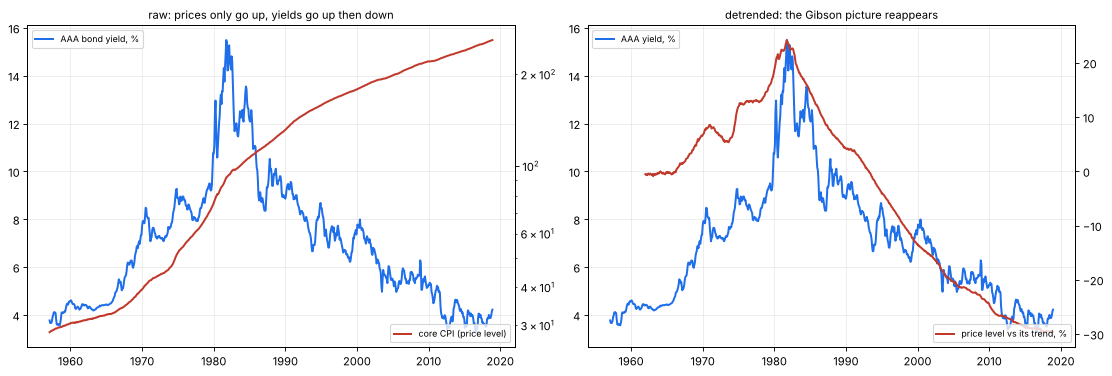

1965-81: corr with raw price +0.92 | with detrended price +0.95 | with inflation +0.86
1982-2018: corr with raw price -0.96 | with detrended price +0.96 | with inflation +0.87


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
ax.plot(us.index, us["aaa"], color="#1f6feb", lw=1.8, label="AAA bond yield, %")
ax2 = ax.twinx()
ax2.plot(us.index, us["cpi"], color="#c0392b", lw=1.8, label="core CPI (price level)")
ax2.set_yscale("log"); ax2.grid(False)
ax.set_title("raw: prices only go up, yields go up then down", fontsize=10)
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
ax = axes[1]
ax.plot(us.index, us["aaa"], color="#1f6feb", lw=1.8, label="AAA yield, %")
ax2 = ax.twinx()
ax2.plot(us.index, us["gap_exp"], color="#c0392b", lw=1.8, label="price level vs its trend, %")
ax2.grid(False)
ax.set_title("detrended: the Gibson picture reappears", fontsize=10)
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()
for name, (a, b) in {"1965-81": data.GREAT_INFLATION, "1982-2018": data.DISINFLATION}.items():
    c = st.level_correlations(us, "aaa", ("logp", "gap_exp", "pi"), a, b)
    print(f"{name}: corr with raw price {c['logp']:+.2f} | with detrended price "
          f"{c['gap_exp']:+.2f} | with inflation {c['pi']:+.2f}")

Under fiat money the raw price level only goes up, so it "correlates" positively with yields while
yields rise (1965-81) and negatively while they fall (1982-2018). Measured against its own trend,
the price level tracks yields beautifully. That is the modern paradox. Now the question is whether
the beautiful line means anything.

### 4.2 How easy it is to fool yourself

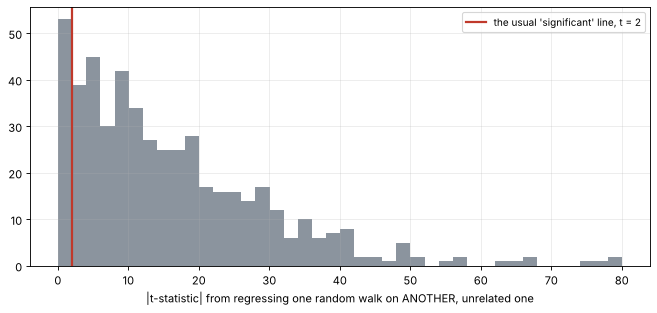

90% of 500 pairs of unrelated random walks look 'significant'.


In [3]:
rng = np.random.default_rng(1974)
ts = []
for _ in range(500):
    a = np.cumsum(rng.normal(size=600)); b = np.cumsum(rng.normal(size=600))
    ts.append(st.hac_ols(a, b, lags=0)["t"][1])
ts = np.abs(np.array(ts))
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(np.clip(ts, 0, 80), bins=40, color="#8b949e")
ax.axvline(2, color="#c0392b", lw=2, label="the usual 'significant' line, t = 2")
ax.set_xlabel("|t-statistic| from regressing one random walk on ANOTHER, unrelated one")
ax.legend(fontsize=9); plt.show()
print(f"{(ts > 2).mean():.0%} of 500 pairs of unrelated random walks look 'significant'.")

These are pairs of **completely unrelated** random series, and most of them look "significantly"
related. Yields and the price level are both series of this drifting kind (the quant notebook runs
the formal unit-root tests). So the correlation in 4.1 is, by itself, worth nothing.

> 🔬 **For the quants.** This is Granger & Newbold (1974). The fix is to test for
> cointegration and to work in first differences — §3-§4 of the quant notebook.

### 4.3 Test 1 — do they share a trend for a reason?

In [4]:
rows = []
for lab, x in (("price level vs trend", us["gap_exp"]), ("12-month inflation", us["pi"]),
               ("slow inflation expectation (3-yr memory)", us["ewma"])):
    r = st.engle_granger(us["aaa"], x)
    rows.append({"yield tied to...": lab, "naive t (the trap)": r["naive_t"],
                 "cointegration p-value": r["eg_p"]})
print(pd.DataFrame(rows).to_string(index=False))

                        yield tied to...  naive t (the trap)  cointegration p-value
                    price level vs trend              36.848                  0.194
                      12-month inflation              24.447                  0.275
slow inflation expectation (3-yr memory)              61.423                  0.009


A small p-value means the yield and the variable really are tied together in the long run. The
price gap is **not** (p ≈ 0.19), despite a naive t-statistic of +36.8. But a
*slow-moving average of past inflation* — what investors might reasonably expect inflation to be
if they learn slowly — **is** (p ≈ 0.009).

That is exactly how Irving Fisher answered Gibson in 1930: people's inflation expectations adjust
over years, so yields track a long, smoothed memory of inflation — which, drawn on a chart, looks
just like the price level.

### 4.4 Test 2 — do the changes line up?

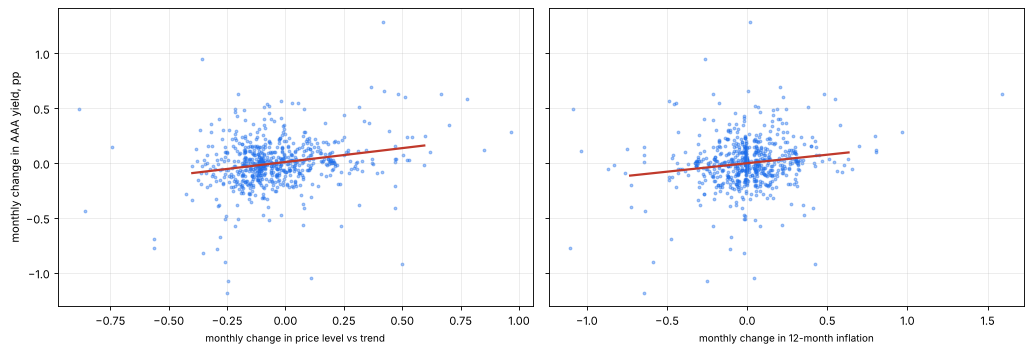

US, both in the race:   price-level t +3.56 | inflation t +0.38
Germany, both in race:  price-level t +0.07 | inflation t -1.00


In [5]:
d = us[["aaa", "gap_exp", "pi"]].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, col, lab in ((axes[0], "gap_exp", "monthly change in price level vs trend"),
                     (axes[1], "pi", "monthly change in 12-month inflation")):
    ax.scatter(d[col], d["aaa"], s=6, alpha=0.4, color="#1f6feb")
    b = np.polyfit(d[col], d["aaa"], 1)
    xs = np.linspace(d[col].quantile(0.01), d[col].quantile(0.99), 50)
    ax.plot(xs, np.polyval(b, xs), color="#c0392b", lw=2)
    ax.set_xlabel(lab, fontsize=9)
axes[0].set_ylabel("monthly change in AAA yield, pp")
plt.tight_layout(); plt.show()
hr = st.diff_horse_race(us, "aaa", "gap_exp", "pi")
print(f"US, both in the race:   price-level t {hr['t_gap']:+.2f} | inflation t {hr['t_pi']:+.2f}")
hd = st.diff_horse_race(de, "R", "gap_exp", "pi", lags=4)
print(f"Germany, both in race:  price-level t {hd['t_gap']:+.2f} | inflation t {hd['t_pi']:+.2f}")

In the US, months with a big price jump are months when yields rise, and that beats the change in
the inflation *rate* as an explanation. In Germany neither variable explains anything. The US
result is a genuine fact about the data — but notice that "this month's price jump" is just this
month's inflation, which is also what moves a slow inflation expectation. The two stories make
the same prediction month to month.

### 4.5 Test 3 — could you have used it in real time?

In [6]:
lag = st.add_publication_lag(us, cols=("gap_exp", "gap_rol", "pi", "ewma"))
tbl, fc = st.oos_table(lag, "aaa", 12, 120, variables=("gap_exp", "gap_rol", "pi", "ewma"))
names = {"gap_exp": "price vs long trend", "gap_rol": "price vs 10-yr trend",
         "pi": "12-month inflation", "ewma": "slow inflation expectation"}
out = tbl[["oos_r2_vs_yield_only", "cw_p"]].rename(index=names)
out.columns = ["forecast improvement (R² vs yield alone)", "p-value"]
print(out.to_string())

                            forecast improvement (R² vs yield alone)  p-value
variable                                                                     
price vs long trend                                            0.035    0.000
price vs 10-yr trend                                          -0.092    0.821
12-month inflation                                             0.069    0.011
slow inflation expectation                                     0.086    0.000


Measured against its full-history trend, the price level does help forecast next year's yield
change in real time. But measured against a 10-year trend — the same idea, a different but equally
reasonable ruler — it does not (p ≈ 0.82). An edge that depends on how you draw
the trend line is a fragile edge.

## 5 · The verdict

**Signal: Mixed** — *a US-only shadow of Fisher.* On the US tape the detrended price level beats 12-month inflation in first differences (Newey-West t +3.56 vs +0.38) and out of sample (Clark-West p 0.000); in Germany 1972-98 it shows nothing (t +0.07). Yields are **not** cointegrated with the price gap (Engle-Granger p 0.19) but **are** with a slow, adaptive inflation expectation (p 0.009) — Fisher's own 1930 explanation of the paradox. Detrend over a rolling 10-year window instead and the forecasting edge vanishes (p 0.82).

It is **Mixed**, not Real, because the result splits by country (US yes, Germany no) and because
the US half reads better as Fisher with a long memory than as a law about price levels.

## 6 · Could you trade it?

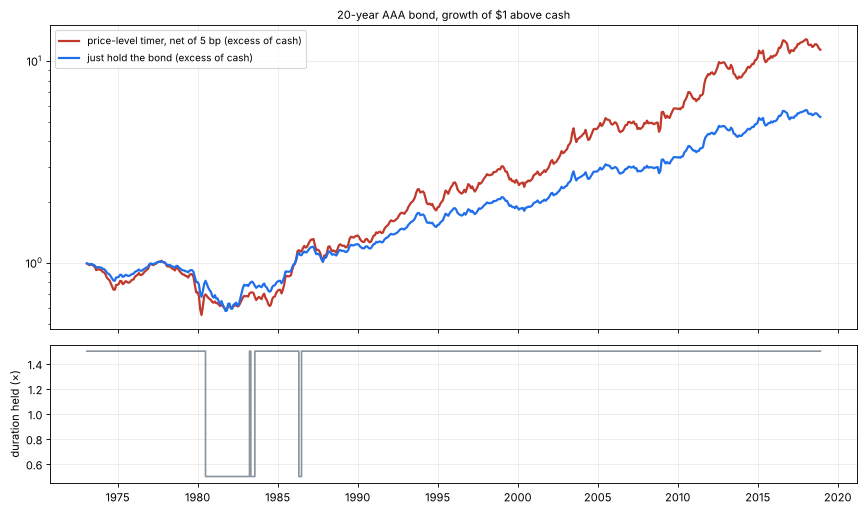

extra return vs holding: +1.95% a year (t +2.63)
   1965-81: -0.05% a year
   1982-2018: +2.44% a year
average duration held 1.43x, trades 0.13x a year


In [7]:
bond = st.bond_returns(us["aaa"], us["rf"])
pos = st.timing_positions(fc["gap_exp"])
bt = st.timing_backtest(bond, pos, cost_bps=5.0)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
ax = axes[0]
ax.plot(bt.index, (1 + bt["net"]).cumprod(), color="#c0392b", lw=2,
        label="price-level timer, net of 5 bp (excess of cash)")
ax.plot(bt.index, (1 + bt["const"]).cumprod(), color="#1f6feb", lw=2,
        label="just hold the bond (excess of cash)")
ax.set_yscale("log"); ax.legend(fontsize=9)
ax.set_title("20-year AAA bond, growth of $1 above cash", fontsize=10)
axes[1].step(bt.index, bt["pos"], where="post", color="#8b949e")
axes[1].set_ylabel("duration held (×)")
plt.tight_layout(); plt.show()
s = st.timing_summary(bt, splits={"1965-81": data.GREAT_INFLATION,
                                  "1982-2018": data.DISINFLATION})
print(f"extra return vs holding: {s['diff_net_ann']:+.2%} a year (t {s['diff_net_t']:+.2f})")
for k, v in s["subs"].items():
    print(f"   {k}: {v['diff_net_ann']:+.2%} a year")
print(f"average duration held {s['mean_pos']:.2f}x, trades {s['turnover_ann']:.2f}x a year")

The timer did beat simply holding the bond. Look at the bottom panel, though: it went long
duration in the 1980s and essentially **stayed there** while yields fell for thirty-five years. It
made nothing in the 1965-81 inflation, the one period where yields went the "wrong" way. Strip out
the extra duration it was carrying and the skill left over is +0.65% a year with a
t-statistic of +1.01 — indistinguishable from luck.

**Tradability: Fragile.** A duration overlay on a 20-year AAA bond earns +1.95% a year net over constant duration (t +2.63; net Sharpe 0.54 vs 0.50), but it sits at 1.43× duration on average, trades 0.13× a year, has an alpha of only +0.65% (t +1.01) after its extra duration, and made -0.05% a year in 1965-81 against +2.44% in 1982-2018. One secular trade, not a repeatable rule.

> 🔬 **For the quants.** Excess-vs-excess Sharpe, one execution lag plus a one-month CPI
> lag, 5 bp one-way per unit traded, and a duration-plus-convexity approximation for the bond.
> The cost sweep and the yield-only control timer are in §6 of the quant notebook.

## 7 · Going further 🚪

- **Test the gold standard.** Add a pre-1914 price index (e.g. UK wholesale prices) and the
  Moody's tape back to 1919 — the paradox should come back where Barsky & Summers say it lives.
- **Model expectations directly.** Survey expectations (Michigan, SPF) instead of a smoothed
  average would settle whether "price level" or "slow expectations" is the better story.
- **More countries.** One German sample of 27 years is thin; a panel of fiat-era bond markets
  would give the cross-country leg real power.
- **Fork it:** everything runs offline from frozen tapes — `examples/verify.py` regenerates every
  number in under three minutes.